
# **IMAGE PROCESSING**
Image Processing = teknik memanipulasi gambar digital supaya jad
i lebih berguna: diperbaiki, dianalisis, atau diekstrak informasinya.

**1. Konsep Dasar Image Processing**

*   Piksel & Channel: elemet terkecil suatu matrik gambar, bisa 1 atau 3 channel
*   RGB = 3 channel: Red, Green, Blue
*   Grayscale = 1 channel
*   Resolusi: Jumlah piksel, misal 500x300



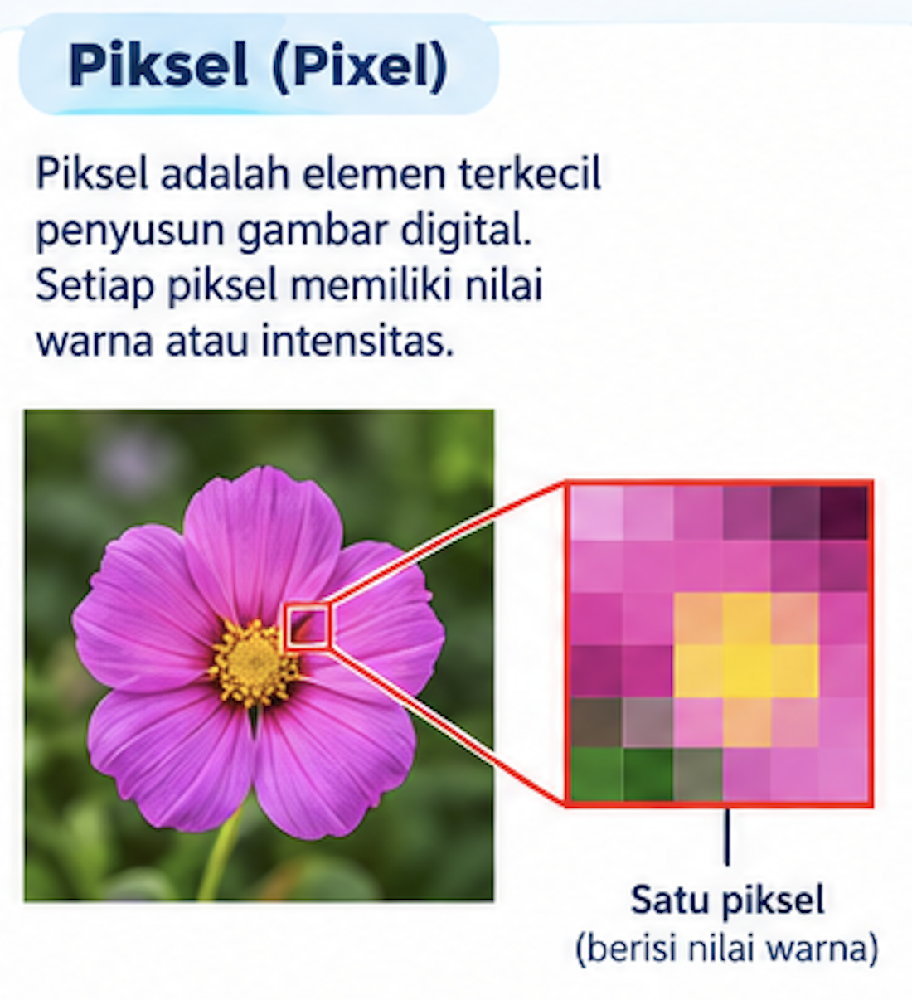

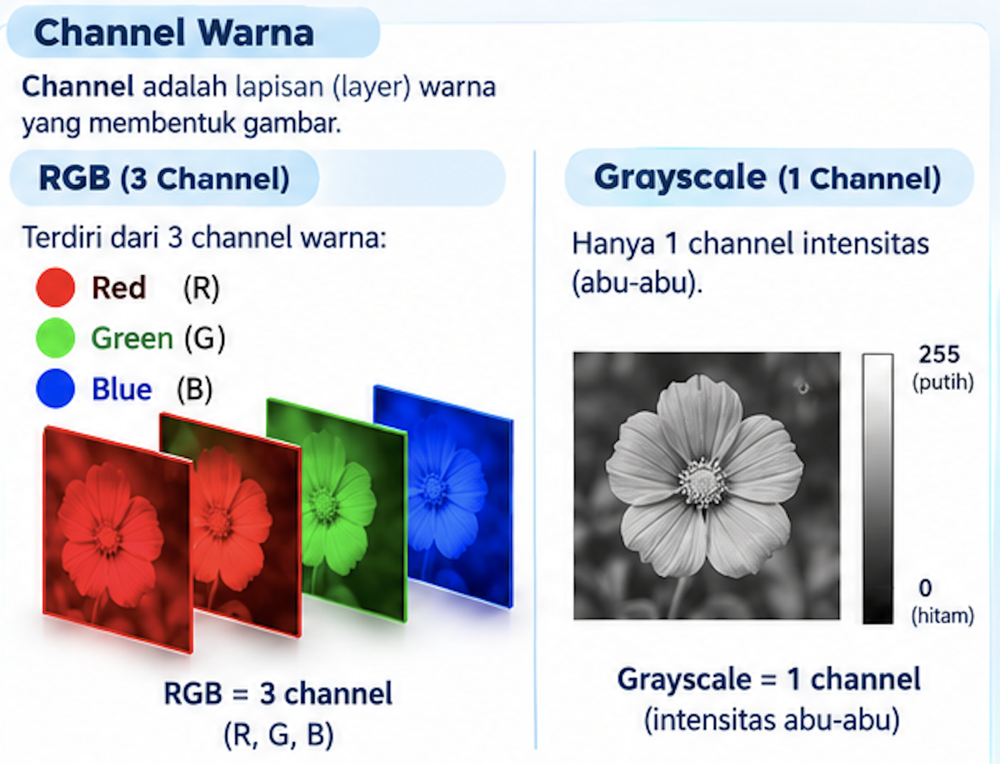

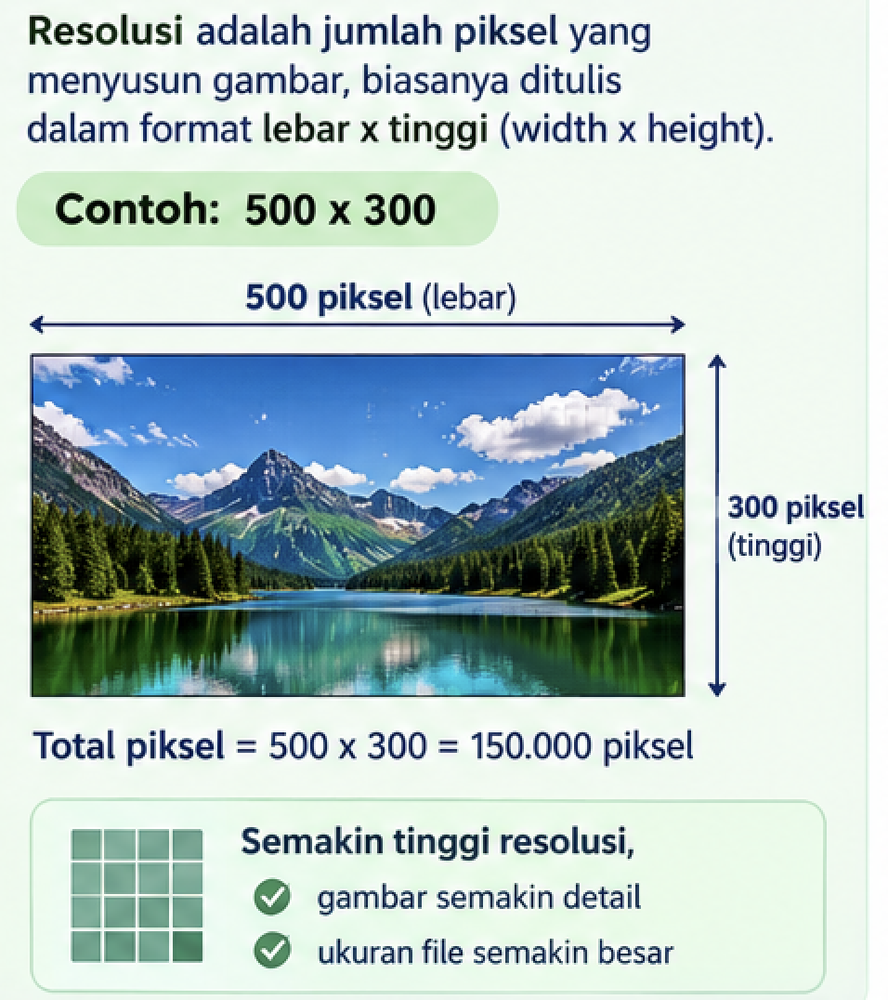

**2. Pipeline Umum Image Processing**
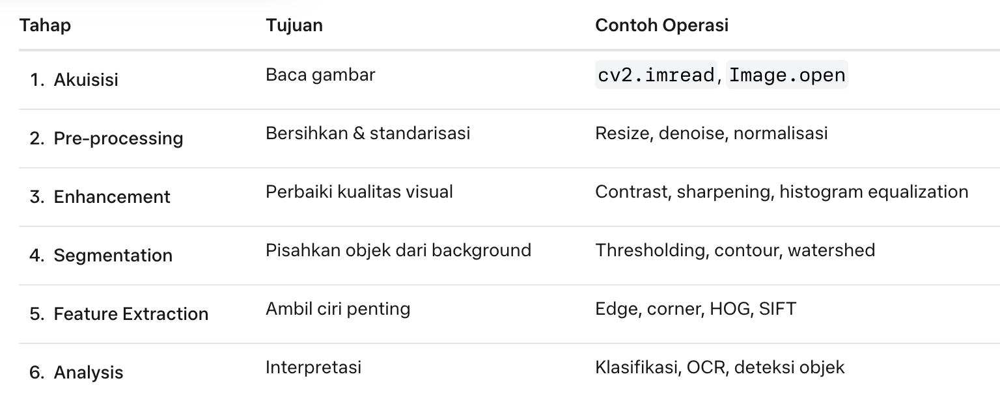

**3. Akuisis Image**

Mengakses data-data pada image dapat digunakan bahasa pemrograman misal : Python

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
!ls /content/drive/MyDrive/PASCA/IP

arhan_gray.jpeg  arhan.jpeg  ip01.ipynb


In [11]:
# import library yg dibutuhkan
import cv2
from google.colab.patches import cv2_imshow

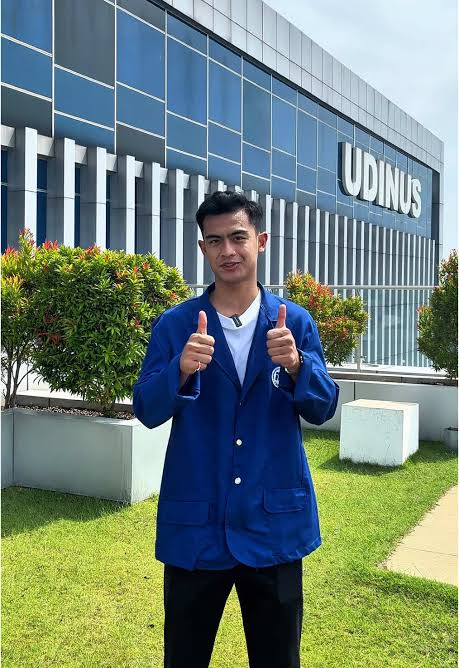

In [38]:
# Membaca image
img = cv2.imread("/content/drive/MyDrive/PASCA/IP/arhan.jpeg")

# Menggunakan cv2_imshow dari Google Colab untuk menampilkan gambar
cv2_imshow(img)

In [31]:
print("--- METADATA CITRA ---")
print(f"Dimensi (Tinggi, Lebar, Channel): {img.shape}")
print(f"Dimensi (Tinggi) : {img.shape[0]}")
print(f"Dimensi (Lebar) : {img.shape[1]}")
print(f"Dimensi (Channel) : {img.shape[2]}")

print(f"Jumlah Piksel : {img.size}")
print(f"Nilai Piksel di koordinat (y=0, x=0) [B, G, R]: {img[0, 0]}")

--- METADATA CITRA ---
Dimensi (Tinggi, Lebar, Channel): (668, 459, 3)
Dimensi (Tinggi) : 668
Dimensi (Lebar) : 459
Dimensi (Channel) : 3
Jumlah Piksel : 919836
Nilai Piksel di koordinat (y=0, x=0) [B, G, R]: [255 242 206]


In [24]:
# Melihat matrik seluruh data piksel
print(img)

[[[255 242 206]
  [132  96  58]
  [150 111  73]
  ...
  [243 233 216]
  [244 235 221]
  [255 253 240]]

 [[255 242 206]
  [132  96  58]
  [150 111  73]
  ...
  [243 233 216]
  [244 235 221]
  [255 253 240]]

 [[255 242 206]
  [132  96  58]
  [150 111  73]
  ...
  [243 233 216]
  [244 235 221]
  [255 253 240]]

 ...

 [[180 255 250]
  [107 193 181]
  [ 40 135 120]
  ...
  [ 53 143 124]
  [ 71 142 126]
  [197 245 233]]

 [[170 254 242]
  [ 79 169 156]
  [ 52 151 135]
  ...
  [ 94 185 164]
  [ 96 170 152]
  [216 255 252]]

 [[174 255 248]
  [ 83 173 160]
  [ 81 183 166]
  ...
  [ 65 156 135]
  [ 59 133 115]
  [191 239 227]]]


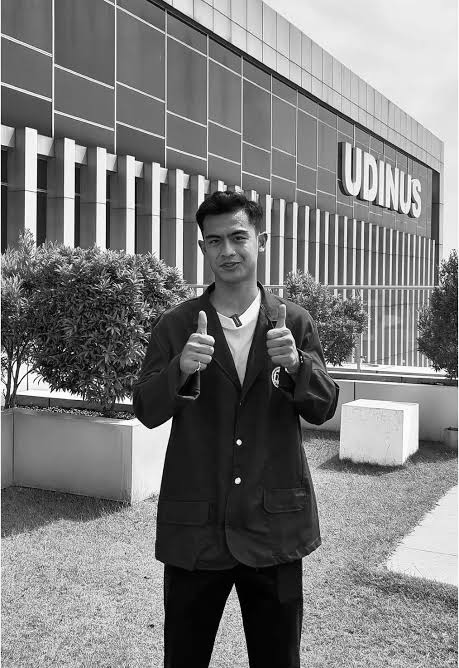

--- METADATA CITRA GRAYSCALE ---
Dimensi (Tinggi, Lebar): (668, 459)
Jumlah Channel: 1


In [43]:
# Mengonversi image BGR ke Grayscale (1 channel)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Menampilkan hasil gambar grayscale
cv2_imshow(img_gray)

# Menampilkan dimensi citra hasil konversi
print("--- METADATA CITRA GRAYSCALE ---")
print(f"Dimensi (Tinggi, Lebar): {img_gray.shape}")
print(f"Jumlah Channel: {1 if len(img_gray.shape) == 2 else img_gray.shape[2]}")

In [44]:
# Menyimpan gambar grayscale ke Google Drive
save_path = "/content/drive/MyDrive/PASCA/IP/arhan_gray.jpeg"
cv2.imwrite(save_path, img_gray)

print(f"Gambar berhasil disimpan di: {save_path}")

Gambar berhasil disimpan di: /content/drive/MyDrive/PASCA/IP/arhan_gray.jpeg


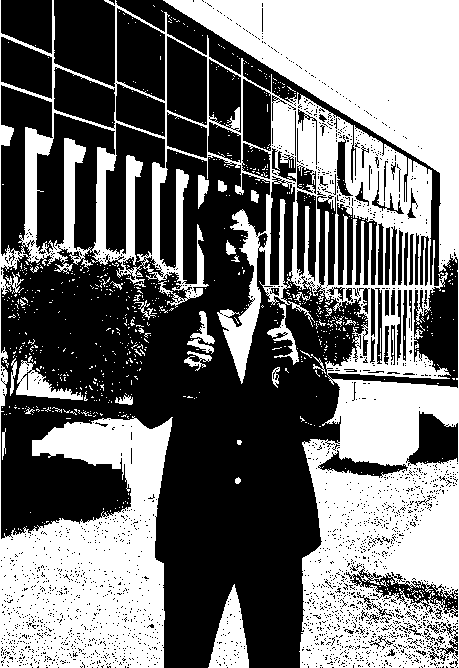

--- METADATA CITRA BLACK & WHITE ---
Dimensi (Tinggi, Lebar): (668, 459)
Nilai ambang batas: 127.0


In [50]:
# Mengubah citra grayscale menjadi Black & White (Biner)
# Piksel di atas 127 akan menjadi 255 (putih), sisanya menjadi 0 (hitam)
ret, img_bw = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Menampilkan hasil gambar hitam putih
cv2_imshow(img_bw)

# Menampilkan dimensi citra hasil konversi
print("--- METADATA CITRA BLACK & WHITE ---")
print(f"Dimensi (Tinggi, Lebar): {img_bw.shape}")
print(f"Nilai ambang batas: {ret}")



**4. Pre-processing**

**Resize**

--- MENAMPILKAN GAMBAR HASIL RESIZE ---


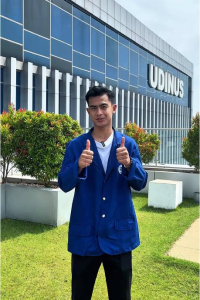


--- METADATA GAMBAR SETELAH RESIZE ---
Dimensi Baru (Tinggi, Lebar, Channel): (300, 200, 3)


In [56]:
# Menentukan dimensi baru untuk resize (Lebar, Tinggi)
dim_baru = (200, 300)

# Mengubah ukuran gambar menggunakan cv2.resize
img_resized = cv2.resize(img, dim_baru, interpolation=cv2.INTER_AREA)

print("--- MENAMPILKAN GAMBAR HASIL RESIZE ---")
cv2_imshow(img_resized)

print("\n--- METADATA GAMBAR SETELAH RESIZE ---")
print(f"Dimensi Baru (Tinggi, Lebar, Channel): {img_resized.shape}")

**Denoising**

Untuk mereduksi bising (denoising) pada citra berwarna, kita dapat menggunakan algoritma yang sangat populer di OpenCV, yaitu Non-Local Means Denoising (cv2.fastNMeansDenoisingColored).

Metode ini bekerja dengan mencari kesamaan pola di seluruh bagian gambar untuk menyaring bising (noise) tanpa mengaburkan tepi objek (edges) secara berlebihan.

--- MENAMPILKAN PERBANDINGAN DENOISING ---
1. Gambar Sebelum Denoise:


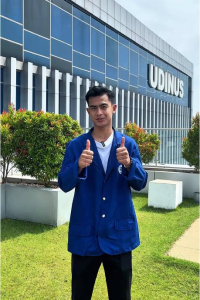


2. Gambar Setelah Denoise:


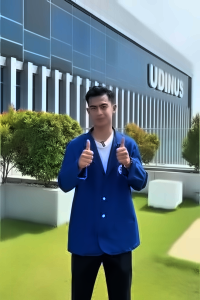

In [61]:
# Melakukan Denoising menggunakan Non-Local Means Denoising untuk citra berwarna
# Fungsi yang benar adalah cv2.fastNlMeansDenoisingColored (menggunakan 'l' kecil)
img_denoised = cv2.fastNlMeansDenoisingColored(img_resized, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)

print("--- MENAMPILKAN PERBANDINGAN DENOISING ---")
print("1. Gambar Sebelum Denoise:")
cv2_imshow(img_resized)

print("\n2. Gambar Setelah Denoise:")
cv2_imshow(img_denoised)

**5. Image Enhancement**

Image Enhancement = memperbaiki kualitas visual gambar supaya lebih mudah dilihat manusia atau lebih siap diproses mesin. Beda dengan Restoration (perbaiki degradasi), Enhancement itu subjektif: bikin gambar "terlihat lebih bagus".

**Operasi Enhancement Image**

**1. Point Operations (per piksel)**

* Brightness Adjustment: tambah/kurangi intensitas semua piksel
* Contrast Stretching: lebarkan rentang intensitas, misal dari jadi
* Gamma Correction: perbaiki gambar terlalu gelap/terang dengan pangkat gamma
* Negative/Inversion: balik intensitas, berguna untuk X-ray/medical
* Log Transform: tekan area terang, angkat area gelap

**2. Histogram-based**

* Histogram Equalization: ratakan distribusi piksel supaya kontras merata
* CLAHE (Contrast Limited Adaptive HE): versi lokal, bagus untuk medical image, tidak over-amplify noise
* Histogram Matching: samakan histogram gambar A dengan gambar B

**3. Spatial Filtering (neighborhood)**

* Smoothing: Gaussian blur, Median filter untuk kurangi noise halus
* Sharpening: Laplacian, Unsharp Masking, High-boost filtering untuk tegaskan edge/detail

**4. Frequency Domain**

* High-pass Filter: pertajam detail
* Low-pass Filter: haluskan



**Kecerahan**

--- MENAMPILKAN GAMBAR DENGAN KECERAHAN BERBEDA ---
1. Gambar Lebih Terang (+50)


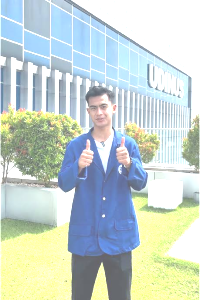

2. Gambar Lebih Gelap (-50)


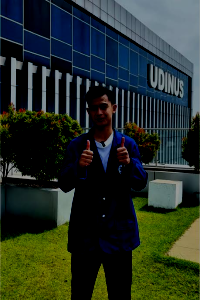

In [57]:
import numpy as np

# Tentukan nilai penambahan kecerahan (misal +50 untuk lebih terang, -50 untuk lebih gelap)
brightness_value = 100

# Modifikasi kecerahan menggunakan numpy dan clipping agar nilai pixel tetap 0 - 255
img_bright = np.clip(img_resized.astype(np.int32) + brightness_value, 0, 255).astype(np.uint8)
img_dark = np.clip(img_resized.astype(np.int32) - brightness_value, 0, 255).astype(np.uint8)

print("--- MENAMPILKAN GAMBAR DENGAN KECERAHAN BERBEDA ---")
print("1. Gambar Lebih Terang (+50)")
cv2_imshow(img_bright)

print("2. Gambar Lebih Gelap (-50)")
cv2_imshow(img_dark)


**Kontras**

--- MENAMPILKAN PENINGKATAN KONTRAS ---
1. Kontras Manual (Alpha = 1.5)


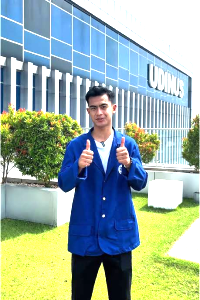

In [59]:
# Peningkatan Kontras Sederhana (Perkalian Pixel dengan Faktor/Alpha)
# Nilai alpha > 1 meningkatkan kontras, alpha < 1 menurunkan kontras
alpha = 1.5
img_contrast = np.clip(img_resized.astype(np.float32) * alpha, 0, 255).astype(np.uint8)

print("--- MENAMPILKAN PENINGKATAN KONTRAS ---")
print("1. Kontras Manual (Alpha = 1.5)")
cv2_imshow(img_contrast)


**NEGATIF / INVERSION**

--- MENAMPILKAN GAMBAR NEGATIF / INVERSION ---
1. Gambar Asli (Resized):


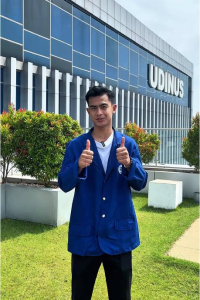


2. Gambar Negatif / Inversion:


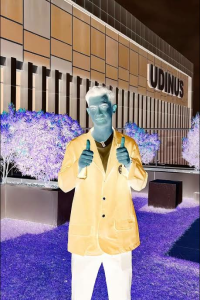

In [62]:
# Membuat gambar negatif (Inversion)
# Rumus: negatif = 255 - nilai_piksel
img_negative = 255 - img_resized

print("--- MENAMPILKAN GAMBAR NEGATIF / INVERSION ---")
print("1. Gambar Asli (Resized):")
cv2_imshow(img_resized)

print("\n2. Gambar Negatif / Inversion:")
cv2_imshow(img_negative)

**Histogram Equalization**

--- MENAMPILKAN HASIL HISTOGRAM EQUALIZATION ---
1. Citra Grayscale Asli:


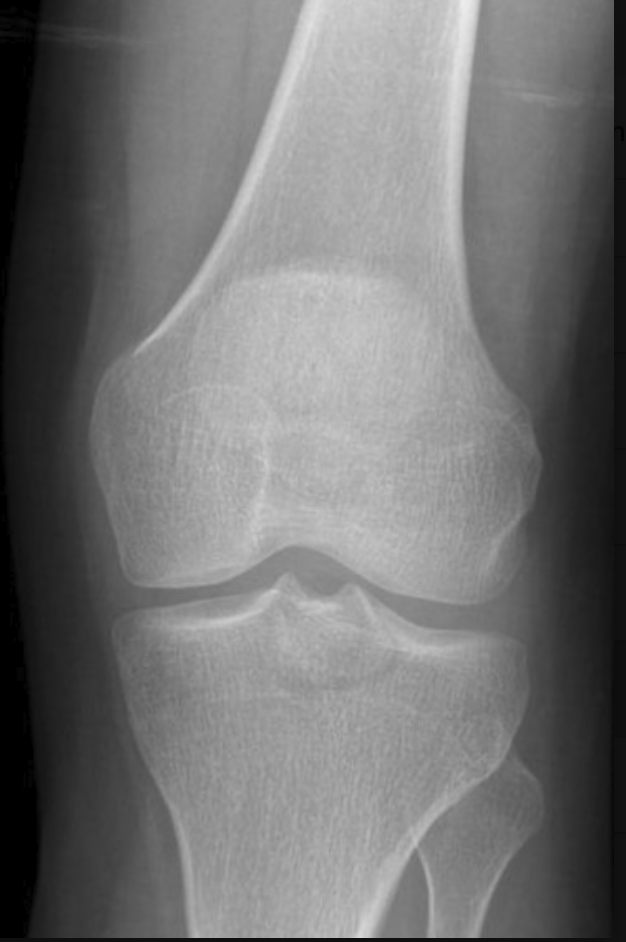


2. Citra Setelah Histogram Equalization:


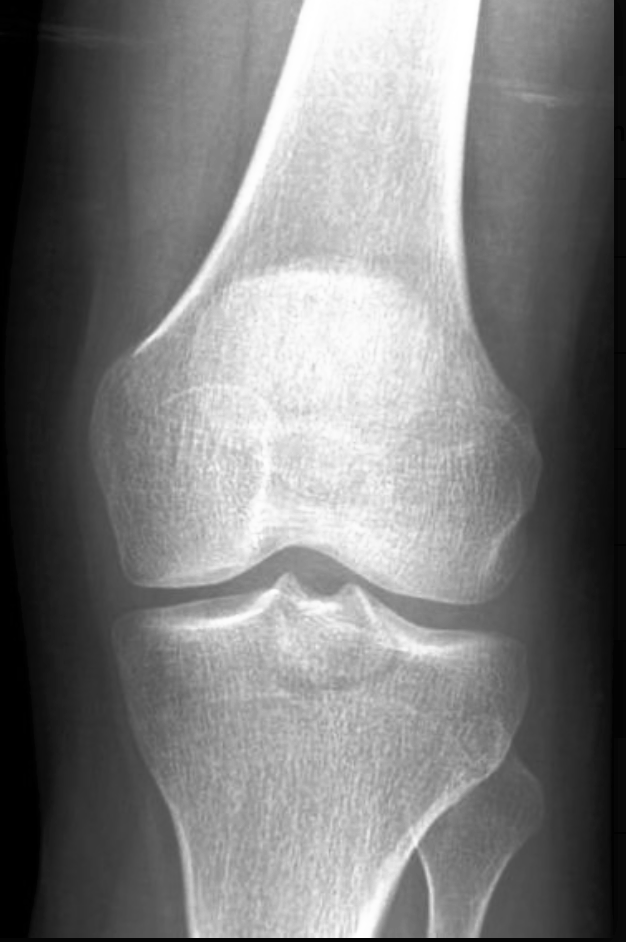

In [77]:
# Membaca image langsung sebagai grayscale (1-channel)
img_tulang = cv2.imread("/content/drive/MyDrive/PASCA/IP/tulang.png", cv2.IMREAD_GRAYSCALE)

# Melakukan Histogram Equalization
img_equalized = cv2.equalizeHist(img_tulang)

print("--- MENAMPILKAN HASIL HISTOGRAM EQUALIZATION ---")
print("1. Citra Grayscale Asli:")
cv2_imshow(img_tulang)

print("\n2. Citra Setelah Histogram Equalization:")
cv2_imshow(img_equalized)

**CLAHE**

contrast limited adaptive histogram equalization

--- PERBANDINGAN METODE PENINGKATAN KONTRAS (DIPERKECIL) ---
1. Citra Grayscale Asli:


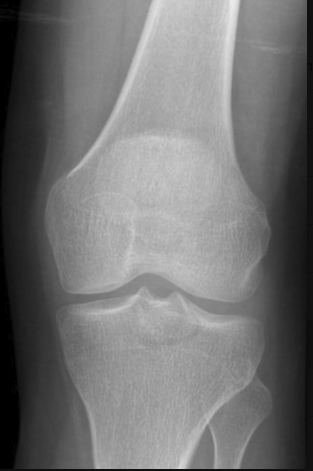


2. Citra Setelah CLAHE (Local & Adaptive):


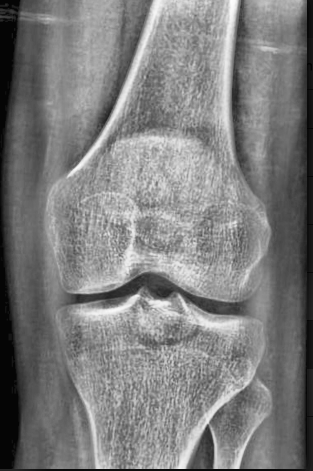

In [73]:
# Inisialisasi objek CLAHE dengan clipLimit (batas kontras) dan tileGridSize (ukuran grid)
# Nilai clipLimit standar adalah 5.0, tileGridSize standar adalah (10, 10)
clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(10, 10))

# Terapkan CLAHE pada gambar grayscale tulang
img_clahe = clahe.apply(img_tulang)

# Tentukan ukuran baru untuk visualisasi (diperkecil 50%)
scale_percent = 50
width = int(img_tulang.shape[1] * scale_percent / 100)
height = int(img_tulang.shape[0] * scale_percent / 100)
dim = (width, height)

# Resize gambar untuk visualisasi
img_tulang_resized = cv2.resize(img_tulang, dim, interpolation=cv2.INTER_AREA)
img_equalized_resized = cv2.resize(img_equalized, dim, interpolation=cv2.INTER_AREA)
img_clahe_resized = cv2.resize(img_clahe, dim, interpolation=cv2.INTER_AREA)

print("--- PERBANDINGAN METODE PENINGKATAN KONTRAS (DIPERKECIL) ---")
print("1. Citra Grayscale Asli:")
cv2_imshow(img_tulang_resized)

print("\n2. Citra Setelah CLAHE (Local & Adaptive):")
cv2_imshow(img_clahe_resized)

Berikut 5 paper terbaru 2023-2026 yang pakai CLAHE sebagai metode utamanya - semuanya masih aktif di Scopus:

**1. Low Illuminance Image Enhancement Algorithm Based on Improved Homomorphic Filtering and CLAHE (2026)**

* Penulis: Zhang Y. et al.
* Sumber: Lecture Notes in Electrical Engineering Vol 1366, Springer - Proceedings of IoTCIT 2024
* Ide: Gabungkan filter homomorphic berbasis Sigmoid + CLAHE. Dipindah ke HSV, buat Gaussian pyramid di channel V, dan stretch channel S biar warna tidak pucat. Diuji di dataset ExDark dan dataset sludge industri. Hasil PSNR, contrast, average gradient jauh lebih tinggi dibanding CLAHE standar dan Retinex
* Kegunaan: Enhancement foto tangki minyak & cerobong asap yang gelap tidak merata.

**2. Luminosity-Adaptive Contrast Enhancement Using CLAHE for Retinal Fundus Images (2026)**

* Penulis: K. Mithra & P.K. Santhanam
* Sumber: Journal of Intelligent Medicine Healthcare Vol 4 No 1, pp 87-97, Tech Science Press
* Ide: Pipeline 2 tahap - koreksi luminosity di HSV space dulu, baru CLAHE. Validasi di multi-dataset fundus (DRIVE, STARE, CHASE_DB1) + uji statistik.
* Kegunaan: Memperjelas pembuluh darah retina untuk screening diabetic retinopathy. Ini paper yang dipresentasikan di ICACCS 2026 kemarin.

**3. Reconstruction of a 3D medical image from pre-processed 2D DICOM slices: clinical application (2024)**

* Penulis: Halloum K. & Ez-Zahraouy H.
* Sumber: International Journal of Medical Engineering and Informatics Vol 16 No 6, pp 571-583
* Ide: Bandingkan 3 versi rekonstruksi 3D MRI: tanpa enhancement, HE saja, HE + CLAHE. Hasil CLAHE terbukti meningkatkan kontras tanpa amplifikasi noise
* Kegunaan: Preprocessing MRI sebelum dibuat volume 3D untuk interpretasi klinis.

**4. Multi-Scale FPGA-Based Infrared Image Enhancement by Using RGF and CLAHE (2023)**

* Penulis: Liu J. et al.
* Sumber: Sensors 2023, 23, 8101
* Ide: Dekomposisi multi-scale dengan Rolling Guidance Filter (RGF) untuk pisah detail dan background, lalu CLAHE untuk enhancement detail. Diimplementasi real-time di FPGA.
* Kegunaan: Enhancement citra inframerah malam hari, deteksi target di militer / surveillance. Terbit September 2023.

**5. Application and Analysis of Medical Image Processing Based on Improved CLAHE (2024)**

* Penulis: Zhao X., Tao S., Ku R., Wei Z.
* Sumber: Lecture Notes in Electrical Engineering - Artificial Intelligence in China 2024
* Ide: Improved CLAHE dengan adaptif clip limit berdasarkan entropy lokal. Diterapkan ke X-ray dan CT.
* Kegunaan: Perbaiki X-ray spine sebelum segmentasi pakai U-Net dan Mask R-CNN. Paper sejenis melaporkan CLAHE + U-Net naik akurasi segmentasi signifikan dibanding HE biasa.

Tren 2023-2026: CLAHE tidak dipakai sendirian lagi. Semua paper di atas hybrid:

* Infrared = RGF + CLAHE
* Low-light = Homomorphic + CLAHE
* Medical = Denoising/RPC/ANN + CLAHE
* Retinal = Luminosity correction + CLAHE

# RGF + CLAHE

*RGF (Rolling Guidance Filter) dan CLAHE (Contrast Limited Adaptive Histogram Equalization)*

adalah kombinasi yang sangat kuat dalam pemrosesan gambar (image processing). Jika digabungkan, keduanya berfungsi sebagai alat restorasi, peningkatan kontras, sekaligus penghilang noise (gangguan) yang sangat halus.

Dalam OpenCV Python, kombinasi ini sering digunakan untuk memperjelas detail medis (seperti hasil X-Ray), memperbaiki foto bawah air, atau meningkatkan akurasi computer vision sebelum proses deteksi objek.

#Mengapa Keduanya Digabungkan ?
* **RGF (Rolling Guidance Filter)**:
Berfungsi untuk menghilangkan tekstur kecil/noise tanpa merusak atau mengaburkan garis tepi objek (edge-preserving smoothing). RGF membuat area permukaan objek menjadi sangat mulus namun batas fisiknya tetap tajam.

* **CLAHE** : Berfungsi untuk meningkatkan kontras lokal secara adaptif. Berbeda dengan Histogram Equalization biasa yang membuat gambar terlalu terang/kontras ekstrem, CLAHE membatasi kontras agar bayangan dan detail halus tetap terlihat natural tanpa memunculkan noise berlebih.

* **Hasil Duet RGF + CLAHE**: Anda akan mendapatkan gambar yang kontrasnya tajam, detailnya menonjol, tetapi permukaannya bersih dari noise / tekstur kasar.

Gagal dengan parameter standar: OpenCV(4.14.0) :-1: error: (-5:Bad argument) in function 'rollingGuidanceFilter'
> Overload resolution failed:
>  - Argument 'd' is required to be an integer
>  - Argument 'd' is required to be an integer

Menggunakan metode alternatif Bilateral Filter secara iteratif (meniru cara kerja dasar RGF)...
1. Gambar Asli:


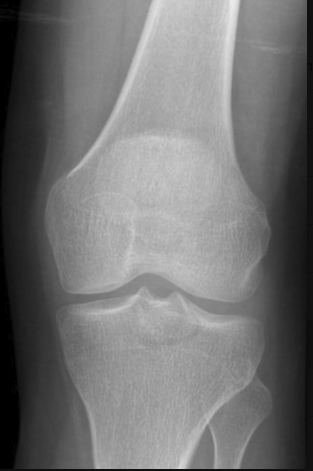


2. Setelah RGF (Mulus):


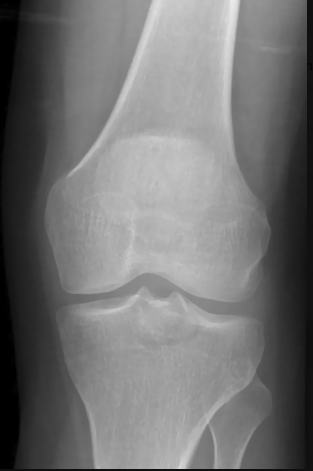


3. Hasil Akhir (RGF + CLAHE):


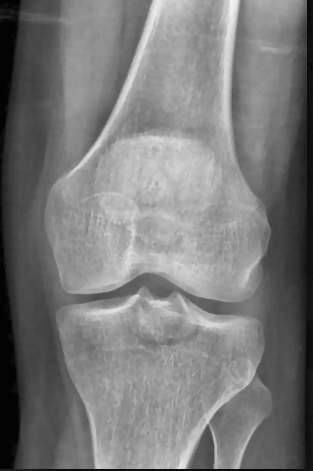

In [86]:
# 1. Baca gambar dalam mode Grayscale (atau bisa diaplikasikan ke channel L pada LAB)
gambar = cv2.imread('/content/drive/MyDrive/PASCA/IP/tulang.png', cv2.IMREAD_GRAYSCALE)

# 2. Terapkan RGF (Rolling Guidance Filter) dengan parameter minimum wajib
# Kita coba panggil hanya dengan parameter dasar (src, d, sigmaColor, sigmaSpace) tanpa argumen iterasi terlebih dahulu
try:
    gambar_rgf = cv2.ximgproc.rollingGuidanceFilter(gambar, 7, 3.0, 3.0)
except Exception as e:
    print(f"Gagal dengan parameter standar: {e}")
    print("Menggunakan metode alternatif Bilateral Filter secara iteratif (meniru cara kerja dasar RGF)...")
    # Alternatif RGF menggunakan Bilateral Filter berulang
    gambar_rgf = gambar.copy()
    for _ in range(4):
        gambar_rgf = cv2.bilateralFilter(gambar_rgf, d=7, sigmaColor=3.0, sigmaSpace=3.0)

# 3. Terapkan CLAHE untuk menaikkan kontras lokal
# clipLimit untuk batas kontras, tileGridSize untuk ukuran blok komputasi
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
hasil_akhir = clahe.apply(gambar_rgf)

# Memperkecil resolusi tampilan menjadi 50% untuk kenyamanan visual di Colab
scale_percent = 50
width = int(gambar.shape[1] * scale_percent / 100)
height = int(gambar.shape[0] * scale_percent / 100)
dim = (width, height)

gambar_resized = cv2.resize(gambar, dim, interpolation=cv2.INTER_AREA)
gambar_rgf_resized = cv2.resize(gambar_rgf, dim, interpolation=cv2.INTER_AREA)
hasil_akhir_resized = cv2.resize(hasil_akhir, dim, interpolation=cv2.INTER_AREA)

# 4. Tampilkan hasil perbandingan menggunakan cv2_imshow khusus Colab
print("1. Gambar Asli:")
cv2_imshow(gambar_resized)

print("\n2. Setelah RGF (Mulus):")
cv2_imshow(gambar_rgf_resized)

print("\n3. Hasil Akhir (RGF + CLAHE):")
cv2_imshow(hasil_akhir_resized)

#Homomorphic + CLAHE
Kombinasi Filter Homomorphic + CLAHE adalah teknik tingkat tinggi yang digunakan untuk mengatasi masalah pencahayaan yang tidak merata (koreksi iluminasi) sekaligus menonjolkan detail lokal yang redup.
Kombinasi ini bekerja dengan sangat cerdas karena menyelesaikan dua masalah pencahayaan dari sudut pandang yang berbeda:
1. **Filter Homomorphic (Global/Frekuensi)**: Memisahkan elemen pencahayaan (illumination) yang biasanya berfrekuensi rendah (seperti bayangan besar atau sorotan lampu di satu sisi) dari elemen reflektansi objek (reflectance) yang berfrekuensi tinggi (detail objek). Filter ini bertugas meratakan pencahayaan di seluruh gambar.
2. **CLAHE (Lokal/Spasial)**: Setelah pencahayaannya rata, CLAHE masuk untuk mempertajam kontras lokal dan memunculkan detail kecil di area yang tadinya terlalu gelap atau terlalu terang.

**Cara Implementasi Homomorphic + CLAHE di Python (OpenCV)**

Karena OpenCV tidak memiliki fungsi bawaan instan untuk Filter Homomorphic, kita perlu membuatnya secara manual menggunakan FFT (Fast Fourier Transform) untuk mengubah gambar ke domain frekuensi, lalu menerapkan filter High-Pass Gaussian.
Berikut adalah kode lengkap untuk gambar skala keabuan (grayscale):

1. Gambar Asli (Pencahayaan Buruk):


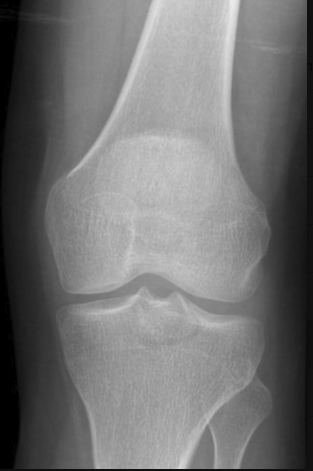


2. Setelah Homomorphic (Pencahayaan Rata):


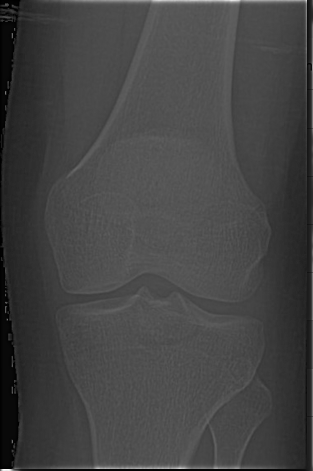


3. Hasil Akhir (Homomorphic + CLAHE):


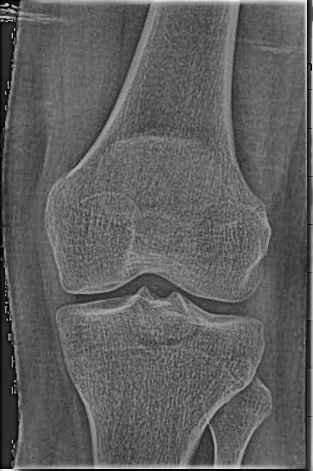

In [90]:
def homomorphic_filter(img, sigma=10, rl=0.5, rh=1.5, c=1):
    # 1. Ubah ke domain logaritmik (ditambah 1 agar tidak log(0))
    img_log = np.log1p(np.float32(img))

    # 2. Ambil FFT (Fast Fourier Transform)
    dft = np.fft.fft2(img_log)
    dft_shift = np.fft.fftshift(dft)

    # 3. Buat High-Pass Filter Gaussian
    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2
    y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    d2 = x**2 + y**2

    # Rumus Homomorphic: H(u,v) = (Rh - Rl) * (1 - exp(-c * (D^2 / sigma^2))) + Rl
    h_filter = (rh - rl) * (1 - np.exp(-c * (d2 / (2 * (sigma**2))))) + rl

    # 4. Aplikasikan filter ke gambar di domain frekuensi
    dft_filtered = dft_shift * h_filter

    # 5. Kembalikan ke domain spasial (Inverse FFT)
    dft_ishift = np.fft.ifftshift(dft_filtered)
    img_back = np.fft.ifft2(dft_ishift)
    img_back = np.real(img_back)

    # 6. Kembalikan dari domain logaritmik (Eksponensial)
    img_exp = np.expm1(img_back)

    # 7. Normalisasi ke rentang 0-255 uint8
    img_normalized = cv2.normalize(img_exp, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(img_normalized)

# --- ALUR UTAMA ---
# 1. Baca gambar asli dalam format grayscale (menggunakan file riil yang ada di Drive)
path_gambar = '/content/drive/MyDrive/PASCA/IP/tulang.png'
gambar = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)

if gambar is None:
    print(f"Gagal memuat gambar dari path: {path_gambar}. Silakan periksa kembali jalurnya.")
else:
    # Perkecil gambar menjadi 50% untuk efisiensi visualisasi di Colab
    scale_percent = 50
    width = int(gambar.shape[1] * scale_percent / 100)
    height = int(gambar.shape[0] * scale_percent / 100)
    gambar_resized = cv2.resize(gambar, (width, height), interpolation=cv2.INTER_AREA)

    # 2. Jalankan Filter Homomorphic untuk meratakan pencahayaan/bayangan ekstrem
    gambar_homomorphic = homomorphic_filter(gambar_resized, sigma=30, rl=0.4, rh=1.5, c=1)

    # 3. Jalankan CLAHE untuk menajamkan kontras detail lokal yang sudah rata
    clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(10, 10))
    hasil_akhir = clahe.apply(gambar_homomorphic)

    # 4. Tampilkan Perbandingan menggunakan cv2_imshow bawaan Colab
    print("1. Gambar Asli (Pencahayaan Buruk):")
    cv2_imshow(gambar_resized)

    print("\n2. Setelah Homomorphic (Pencahayaan Rata):")
    cv2_imshow(gambar_homomorphic)

    print("\n3. Hasil Akhir (Homomorphic + CLAHE):")
    cv2_imshow(hasil_akhir)